# A century of baseball: dating the home-run regime shifts

The Major League Baseball home-run rate has a rich regime structure. It has been reshaped repeatedly by rule changes, equipment, new ballparks and performance-enhancing drugs. The associated folklore is well known: a "dead-ball" era of bunts and singles, an abrupt 1920 "live-ball" revolution, the 1968 "Year of the Pitcher", and the late-twentieth-century steroid era. Here we ask whether a single time-varying parameter, inferred with *bayesloop*, can reconstruct this century and a half of history and date its two most consequential structural breaks from the data alone.

This is a natural fit for a time-varying-parameter model. The home-run rate is one number per season, but the process generating it clearly changes over time, sometimes smoothly and sometimes in a jump. We let the rate drift and use the marginal likelihood (model evidence) to decide whether the data prefer a constant level, a gradually varying one, or a single break, and then run focused `ChangepointStudy` scans to put a date, with a posterior, on the live-ball and steroid-era transitions. Along the way we exercise the `Gaussian` observation model with an inferred scatter, `HyperStudy`, `ChangepointStudy`, and evidence-based model selection.

In [1]:
%matplotlib inline
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import bayesloop as bl

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.edgecolor": "#444444", "grid.color": "#d9d9d9",
})
C = {"data": "#8a8a8a", "accent": "#c1272d", "accent2": "#0b6e99",
     "green": "#2e7d32", "amber": "#e8a33d", "muted": "#8a8a8a",
     "band": "#c1272d", "band2": "#0b6e99"}


def posterior_band(S, name, lo=0.05, hi=0.95):
    """Posterior mean and an equal-tailed credible band for a time-varying parameter."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mean = (p * x[None, :]).sum(axis=1)
    cdf = np.cumsum(p, axis=1)
    low = np.array([np.interp(lo, cdf[t], x) for t in range(p.shape[0])])
    high = np.array([np.interp(hi, cdf[t], x) for t in range(p.shape[0])])
    return mean, low, high


def prob_in(S, name, lo=None, hi=None):
    """Posterior probability the parameter lies in (lo, hi] at each time step."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mask = np.ones_like(x, dtype=bool)
    if lo is not None:
        mask &= x > lo
    if hi is not None:
        mask &= x <= hi
    return p[:, mask].sum(axis=1)

## The data

We use the Lahman Baseball Database `Teams.csv` table (Chadwick Bureau mirror), which has one row per team per season with that team's games (`G`) and home runs (`HR`). For every season we sum home runs and games across all teams and form home runs per team-game. This rate is directly comparable across eras despite league expansion (8 → 30 teams) and changing schedule lengths, because it is already exposure-normalised. The series runs 1871–2016 (146 seasons). The mirror ends at 2016, so we capture the dead-ball, live-ball, pitcher's-era, steroid and testing regimes; the 2019 "juiced-ball" record peak lies just beyond the window.

In [2]:
url = "https://raw.githubusercontent.com/orrski/baseballdatabank/master/core/Teams.csv"
try:
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (bayesloop docs)"})
    raw = urllib.request.urlopen(req, timeout=90).read()
except Exception:  # noqa: BLE001 — fall back to an alternate mirror
    url = "https://raw.githubusercontent.com/cbwinslow/baseballdatabank/master/core/Teams.csv"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (bayesloop docs)"})
    raw = urllib.request.urlopen(req, timeout=90).read()
t = pd.read_csv(io.BytesIO(raw))

ag = t.groupby("yearID").agg(HR=("HR", "sum"), TG=("G", "sum")).reset_index()
ag = ag[ag["yearID"] <= 2016]
years = ag["yearID"].values.astype(float)
rate = (ag["HR"] / ag["TG"]).values.astype(float)   # home runs per team-game
print(f"Seasons: {len(years)}  {int(years.min())}-{int(years.max())}")

Seasons: 146  1871-2016


## Modelling the rate: a Gaussian with inferred scatter

A first instinct is to model the season HR totals as Poisson. With thousands of home runs per season, however, a Poisson implies a per-season precision of about 3%, far tighter than the real year-to-year variability driven by parks, balls, weather and rule tweaks. Forcing a Poisson on the totals makes every rigid model underflow. We therefore model the per-game rate HR/team-game with a `Gaussian` observation model whose standard deviation, the season-to-season scatter, is itself a free, inferred parameter (`noise`). This is the same robust treatment used for incidence data elsewhere, here applied to a linear rate.

In [3]:
def obs():
    return bl.om.Gaussian("rate", bl.cint(0.0, 1.5, 300), "noise", bl.oint(0.01, 0.5, 60))

## A smooth time-varying rate over the full history

First we let the rate drift smoothly from season to season with a `GaussianRandomWalk`, wrapped in a `HyperStudy` that marginalises over the unknown magnitude (`sigma`) of that drift. The result is a single inferred curve that traces the arc of baseball offense.

In [4]:
Sr = bl.HyperStudy()
Sr.load_data(rate, timestamps=years)
Sr.set(obs(), bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 0.06, 30), target="rate"))
Sr.fit(silent=True)
r_mean, r_lo, r_hi = posterior_band(Sr, "rate")

+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['rate', 'noise']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


## Letting the evidence choose: constant, gradual, or one break

The smooth fit assumes gradual drift. To test whether the data prefer this, we compare models. Because every model below shares the identical observation model and data, their log₁₀ marginal likelihoods (`S.log10_evidence`) are directly comparable. We compare three hypotheses: a static constant rate, the gradually varying random walk above, and a single change-point, a `ChangepointStudy` that scans every possible break season and returns a posterior over the break year.

In [5]:
# Static (constant) rate — the null hypothesis.
S0 = bl.Study()
S0.load_data(rate, timestamps=years)
S0.set(obs(), bl.tm.Static())
S0.fit(silent=True)

# A single abrupt change-point; ChangepointStudy scans *every* possible break season.
Scp = bl.ChangepointStudy()
Scp.load_data(rate, timestamps=years)
Scp.set(obs(), bl.tm.ChangePoint("t_change", "all"))
Scp.fit(silent=True)
cp_x, cp_p = Scp.get_hyper_parameter_distribution("t_change")
cp_mode = float(cp_x[np.argmax(cp_p)])

evid = {
    "Static (constant)": float(S0.log10_evidence),
    "Gradually varying": float(Sr.log10_evidence),
    "Single change-point": float(Scp.log10_evidence),
}

+ Created new study.
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['rate', 'noise']
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
  --> Change-point analysis
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['rate', 'noise']
+ Transition model: Change-point. Hyper-Parameter(s): ['t_change']
+ Detected 1 change-point(s) in transition model: ['t_change']
+ Set hyper-prior(s): ['uniform']


## Isolating the steroid-era onset

The full-series change-point locks onto the single biggest break in 150 years (the 1920 jump), so it cannot also tell us when the steroid era began. To isolate that later transition we run a second `ChangepointStudy` on a 1980–2004 window, long enough to straddle the surge but short enough that the live-ball jump is excluded. This shows how a windowed change-point scan can pinpoint a specific transition even when many exist in the full record.

In [6]:
mod = ag[(ag["yearID"] >= 1980) & (ag["yearID"] <= 2004)].reset_index(drop=True)
Scp2 = bl.ChangepointStudy()
Scp2.load_data((mod["HR"] / mod["TG"]).values.astype(float),
               timestamps=mod["yearID"].values.astype(float))
Scp2.set(obs(), bl.tm.ChangePoint("t_change", "all"))
Scp2.fit(silent=True)
cp2_x, cp2_p = Scp2.get_hyper_parameter_distribution("t_change")
cp2_mode = float(cp2_x[np.argmax(cp2_p)])

+ Created new study.
  --> Hyper-study
  --> Change-point analysis
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['rate', 'noise']
+ Transition model: Change-point. Hyper-Parameter(s): ['t_change']
+ Detected 1 change-point(s) in transition model: ['t_change']
+ Set hyper-prior(s): ['uniform']


## Quantifying the regimes from the raw series

We can also read a model-free magnitude directly from the data: the mean dead-ball rate (1901–1919) versus the early live-ball rate (1921–1930), and the 1968 pitcher's-year trough versus the 2000 steroid-era peak.

In [7]:
deadball = rate[(years >= 1901) & (years <= 1919)].mean()
liveball = rate[(years >= 1921) & (years <= 1930)].mean()
trough_1968 = rate[years == 1968][0]
peak_2000 = rate[years == 2000][0]

print("\nMODEL EVIDENCE (log10):")
for k, v in evid.items():
    print(f"  {k:22s} {v:10.1f}")
print(f"Dominant change-point: {cp_mode:.0f}  (live-ball revolution)")
print(f"Steroid-era onset change-point (1980-2004 window): {cp2_mode:.0f}")
print(f"Dead-ball {deadball:.3f} -> live-ball {liveball:.3f} HR/team-game "
      f"({liveball/deadball:.1f}x);  1968={trough_1968:.3f}, 2000 peak={peak_2000:.3f}")


MODEL EVIDENCE (log10):
  Static (constant)           -24.5
  Gradually varying            67.6
  Single change-point          17.1
Dominant change-point: 1920  (live-ball revolution)
Steroid-era onset change-point (1980-2004 window): 1993
Dead-ball 0.152 -> live-ball 0.439 HR/team-game (2.9x);  1968=0.614, 2000 peak=1.172


The result is clear. A time-varying rate is favoured over a constant one by a large margin (tens of log₁₀ units), and over a single break by tens more, which confirms quantitatively that baseball offense is a multi-regime system rather than a one-shift one. The two focused change-point scans land squarely on the textbook dates: 1920 for the live-ball revolution (the year the spitball was banned, umpires began swapping out scuffed balls after Ray Chapman's fatal beaning, and Babe Ruth hit a then-astonishing 54 home runs) and 1993 for the steroid-era onset (coincident with the 1993 expansion, the run-up to Coors Field, and the offensive explosion that culminated in the 1998 McGwire–Sosa chase and Bonds' 73 in 2001).

## The home run as one time-varying parameter

The first figure overlays the observed rate (bars) with the single inferred rate (`HyperStudy` posterior mean, red) and its 90% credible band. Read left to right, this one curve traces the history of the home run.

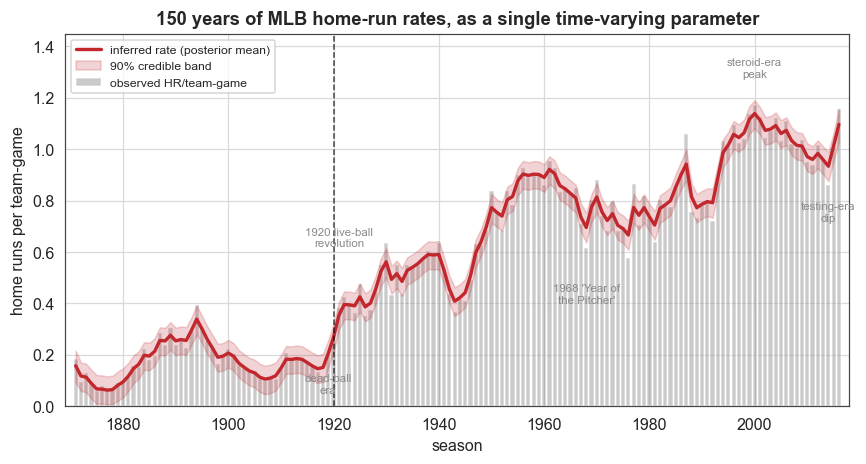

In [8]:
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(years, rate, width=0.8, color=C["muted"], alpha=0.45, label="observed HR/team-game")
ax.plot(years, r_mean, color=C["accent"], lw=2.2, label="inferred rate (posterior mean)")
ax.fill_between(years, r_lo, r_hi, color=C["band"], alpha=0.20, label="90% credible band")
anns = [(1919, 0.05, "dead-ball\nera"), (1921, 0.62, "1920 live-ball\nrevolution"),
        (1968, 0.40, "1968 'Year of\nthe Pitcher'"), (2000, 1.28, "steroid-era\npeak"),
        (2014, 0.72, "testing-era\ndip")]
for xx, yy, txt in anns:
    ax.text(xx, yy, txt, fontsize=7.5, ha="center", color=C["data"])
ax.axvline(cp_mode, color="k", ls="--", lw=1, alpha=0.7)
ax.set_xlim(1869, 2018)
ax.set_ylim(0, 1.45)
ax.set_ylabel("home runs per team-game")
ax.set_xlabel("season")
ax.set_title("150 years of MLB home-run rates, as a single time-varying parameter")
ax.legend(loc="upper left", fontsize=8)
plt.show()

The inferred rate reconstructs the history of baseball offense: the dead-ball era (~0.15 HR/team-game, bottoming out around 1918), the abrupt 1920 jump, the rise through mid-century, the 1968 "Year of the Pitcher" dip, the climb to the steroid-era peak around 2000, the post-2005 testing-era decline, and the 2015–16 rebound.

## The two dated breaks

Finally we show the two change-point posteriors side by side: the full-series scan, which dates the live-ball revolution, and the windowed scan, which dates the steroid-era onset. These are distributions over years, so each transition comes with its own uncertainty, which a hand-defined "era" boundary cannot provide.

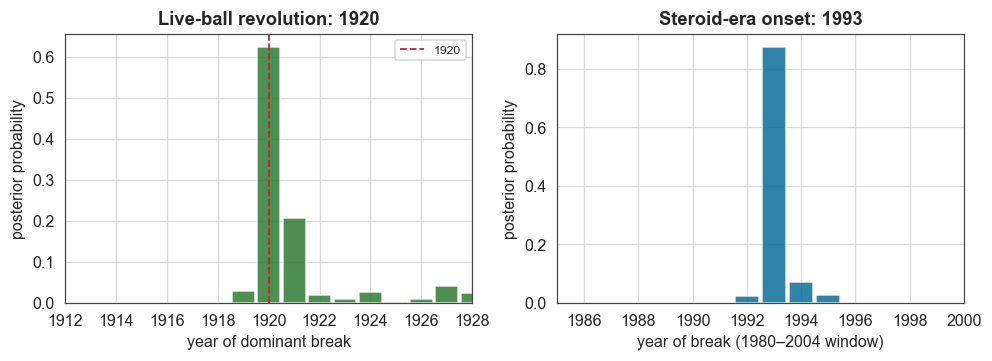

In [9]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9.2, 3.4))
axa.bar(cp_x, cp_p, width=0.9, color=C["green"], alpha=0.85)
axa.axvline(1920, color=C["accent"], ls="--", lw=1.2, label="1920")
axa.set_xlim(1912, 1928)
axa.set_xlabel("year of dominant break")
axa.set_ylabel("posterior probability")
axa.set_title(f"Live-ball revolution: {cp_mode:.0f}")
axa.legend(fontsize=8)
axb.bar(cp2_x, cp2_p, width=0.9, color=C["accent2"], alpha=0.85)
axb.set_xlim(1985, 2000)
axb.set_xlabel("year of break (1980–2004 window)")
axb.set_ylabel("posterior probability")
axb.set_title(f"Steroid-era onset: {cp2_mode:.0f}")
plt.tight_layout()
plt.show()

## What this example showed

On a single, readily interpretable dataset we used *bayesloop* to:

- express baseball folklore as measurement: one continuously varying parameter reconstructs 150 years of home-run history, and the figure traces that history directly;
- settle a structural question with model evidence: a time-varying rate is favoured over both a constant level and a single break by tens of log₁₀ units, which confirms that baseball offense is a multi-regime system;
- date two transitions with posteriors rather than assumptions: full-series and windowed `ChangepointStudy` scans place the live-ball revolution at 1920 and the steroid-era onset at 1993, both within a year of the dates historians cite;
- apply a practical modelling lesson: why a naive Poisson-on-totals model underflows on large counts, and how reframing to a Gaussian rate with inferred scatter fixes it, guidance that transfers to any bayesloop user with large count data.